In [10]:
from __future__ import annotations
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scripts.analysis.rebuttal_neurips2026 import common as C

OUT_DIR = Path(
    "/data/home/cjrisi/nocturnal/scripts/analysis/rebuttal_neurips2026/outputs"
)

df = pd.read_csv(
    "/data/home/cjrisi/nocturnal/scripts/analysis/rebuttal_neurips2026/outputs/a3b_24h_variance.csv"
)

df.head(100)

,dataset,dataset_label,hour,window_label,n,mean_bg,std_bg,cv,hypo_count
0,aleppo_2017,Replace-BG,0,00:00-01:00,524539,9.401484,3.676973,0.391106,17603
1,aleppo_2017,Replace-BG,1,01:00-02:00,528009,9.294598,3.675642,0.395460,20720
2,aleppo_2017,Replace-BG,2,02:00-03:00,529652,9.207274,3.677381,0.399400,21061
3,aleppo_2017,Replace-BG,3,03:00-04:00,530040,9.102253,3.671693,0.403383,21848
4,aleppo_2017,Replace-BG,4,04:00-05:00,529947,8.935591,3.622960,0.405453,22380
...,...,...,...,...,...,...,...,...,...
91,tamborlane_2008,Tamborlane,19,19:00-20:00,688352,8.882582,3.854732,0.433965,29850
92,tamborlane_2008,Tamborlane,20,20:00-21:00,688546,8.898002,3.891753,0.437374,30589
93,tamborlane_2008,Tamborlane,21,21:00-22:00,689539,8.912091,3.891266,0.436628,30748
94,tamborlane_2008,Tamborlane,22,22:00-23:00,693772,8.952574,3.833788,0.428233,29760


In [29]:
# Find the hour with minimum CV for each dataset
min_cv_hour = df.loc[
    df.groupby("dataset")["cv"].idxmin(), ["dataset", "hour"]
].set_index("dataset")["hour"]

# Shift hours so each dataset's minimum-CV hour becomes 0
df["hr_cv_shift"] = (df["hour"] - df["dataset"].map(min_cv_hour) + 8) % 24

# Optional quick check
df[["dataset", "hour", "cv", "hr_cv_shift"]].head(12)

# Find the hour with minimum CV for each dataset
min_bg_hour = df.loc[
    df.groupby("dataset")["mean_bg"].idxmin(), ["dataset", "hour"]
].set_index("dataset")["hour"]

# Shift hours so each dataset's minimum-mean-bg hour becomes 0
df["hr_bg_shift"] = (df["hour"] - df["dataset"].map(min_bg_hour) + 8) % 24

# Optional quick check
df[["dataset", "hour", "mean_bg", "hr_bg_shift"]].head(12)

,dataset,hour,mean_bg,hr_bg_shift
0,aleppo_2017,0,9.401484,1
1,aleppo_2017,1,9.294598,2
2,aleppo_2017,2,9.207274,3
3,aleppo_2017,3,9.102253,4
4,aleppo_2017,4,8.935591,5
5,aleppo_2017,5,8.693120,6
6,aleppo_2017,6,8.440889,7
7,aleppo_2017,7,8.318446,8
8,aleppo_2017,8,8.422389,9
9,aleppo_2017,9,8.598957,10


In [33]:
# Install
!pip install itables

# Use
from itables import init_notebook_mode, show

init_notebook_mode(all_interactive=True)

# Or explicitly
show(df)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.4 MB/s  0:00:00

[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [35]:
def _plot_variance_combined(df: pd.DataFrame, time_col) -> None:
    """Generate a combined variance plot with all datasets on one panel."""
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(12, 6))

    # Color palette for datasets
    colors = {
        "Replace-BG": "#1f77b4",
        "DCLP3": "#ff7f0e",
        "IOBP2": "#2ca02c",
        "Tamborlane": "#d62728",
    }

    for dataset in ["Replace-BG", "DCLP3", "IOBP2", "Tamborlane"]:
        subset = df[df["dataset_label"] == dataset].copy()
        if subset.empty:
            continue
        subset = subset.sort_values(time_col)

        # Extract x (hour) and y (CV)
        x = subset[time_col].values
        y = subset["cv"].values
        label = dataset

        # Plot
        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            markersize=5,
            label=label,
            color=colors.get(label, None),
            alpha=0.8,
        )

    # Highlight evaluation window
    ax.axvspan(0, 8, color="green", alpha=0.1, label="Evaluation window (00:00-08:00)")

    ax.set_xlim(-0.5, 23.5)
    ax.set_xticks(range(0, 24, 1))
    ax.set_xticklabels(
        [f"{h:02d}:00" for h in range(0, 24, 1)], rotation=45, ha="right", fontsize=9
    )
    ax.set_xlabel("Time of Day (Hour)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Coefficient of Variation", fontsize=12, fontweight="bold")
    ax.set_title(
        "24-Hour Blood Glucose Variability Pattern\n"
        "Comparing Nocturnal (00:00-08:00) vs Daytime Variability",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )
    ax.legend(loc="best", fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    # png_path = OUT_DIR / "a3b_24h_variance.png"
    # plt.savefig(png_path, dpi=300, bbox_inches="tight")
    # plt.close()
    # print(f"Saved: {png_path}")


def _plot_mean_combined(df: pd.DataFrame, time_col) -> None:
    """Generate a combined mean blood glucose plot with all datasets on one panel."""
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(12, 6))

    # Color palette for datasets
    colors = {
        "Replace-BG": "#1f77b4",
        "DCLP3": "#ff7f0e",
        "IOBP2": "#2ca02c",
        "Tamborlane": "#d62728",
    }

    for dataset in ["Replace-BG", "DCLP3", "IOBP2", "Tamborlane"]:
        subset = df[df["dataset_label"] == dataset].copy()
        if subset.empty:
            continue
        subset = subset.sort_values(time_col)

        # Extract x (hour) and y (CV)
        x = subset[time_col].values
        y = subset["mean_bg"].values
        label = dataset

        # Plot
        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            markersize=5,
            label=label,
            color=colors.get(label, None),
            alpha=0.8,
        )

    # Highlight evaluation window
    ax.axvspan(0, 8, color="green", alpha=0.1, label="Evaluation window (00:00-08:00)")

    ax.set_xlim(-0.5, 23.5)
    ax.set_xticks(range(0, 24, 1))
    ax.set_xticklabels(
        [f"{h:02d}:00" for h in range(0, 24, 1)], rotation=45, ha="right", fontsize=9
    )
    ax.set_xlabel("Time of Day (Hour)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Mean Blood Glucose (mmol/L)  ", fontsize=12, fontweight="bold")
    ax.set_title(
        "24-Hour Mean Blood Glucose Pattern\n"
        "Comparing Nocturnal (00:00-08:00) vs Daytime Levels",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )
    ax.legend(loc="best", fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    # png_path = OUT_DIR / "a3b_24h_variance.png"
    # plt.savefig(png_path, dpi=300, bbox_inches="tight")
    # plt.close()
    # print(f"Saved: {png_path}")


def _plot_hypoglycemia_counts(df: pd.DataFrame) -> None:
    """Generate bar charts showing hypoglycemia counts by hour for each dataset."""
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes = axes.flatten()

    # First pass: find the global max for consistent y-axis
    global_max = 0
    for dataset in C.DATASETS:
        subset = df[df["dataset"] == dataset].copy()
        if not subset.empty:
            global_max = max(global_max, subset["hypo_count"].max())

    # Add 10% padding to y-axis max
    y_max = global_max * 1.1

    for i, dataset in enumerate(C.DATASETS):
        ax = axes[i]
        subset = df[df["dataset"] == dataset].copy()
        if subset.empty:
            continue
        subset = subset.sort_values("hour")

        # Extract x (hour) and y (hypo count)
        x = subset["hour"].values
        y = subset["hypo_count"].values

        # Bar plot with evaluation window highlighted
        colors_bar = ["#90EE90" if h < 8 else "#4169E1" for h in x]
        ax.bar(x, y, color=colors_bar, alpha=0.7, edgecolor="black", linewidth=0.5)

        # Add reference patches for legend - moved to upper left
        from matplotlib.patches import Patch

        legend_elements = [
            Patch(
                facecolor="#90EE90",
                alpha=0.7,
                edgecolor="black",
                label="Evaluation window (00:00-08:00)",
            ),
            Patch(
                facecolor="#4169E1",
                alpha=0.7,
                edgecolor="black",
                label="Daytime (08:00-24:00)",
            ),
        ]
        ax.legend(handles=legend_elements, loc="upper left", fontsize=9, framealpha=0.9)

        ax.set_xlim(-0.5, 23.5)
        ax.set_ylim(0, y_max)  # Set consistent y-axis across all panels
        ax.set_xticks(range(0, 24, 2))
        ax.set_xticklabels(
            [f"{h:02d}:00" for h in range(0, 24, 2)], rotation=45, ha="right"
        )
        ax.set_xlabel("Hour of Day", fontsize=10)
        ax.set_ylabel("Number of Hypoglycemic Readings", fontsize=10)
        ax.set_title(C.DATASET_LABEL[dataset], fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3, axis="y")

        # Add total count annotation - moved to right side, lower position
        total_hypo = y.sum()
        overnight_hypo = y[:8].sum()
        overnight_pct = 100 * overnight_hypo / total_hypo if total_hypo > 0 else 0
        ax.text(
            0.98,
            0.70,
            f"Total hypo readings: {total_hypo:,}\n"
            f"Overnight (00:00-08:00): {overnight_hypo:,} ({overnight_pct:.1f}%)",
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="top",
            horizontalalignment="right",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
        )

    fig.suptitle(
        "Hypoglycemia Event Distribution by Hour of Day\n"
        "Number of BG readings < 3.9 mmol/L",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    png_path = OUT_DIR / "a3b_24h_hypoglycemia_counts.png"
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved: {png_path}")


def _plot_hypoglycemia_normalized(df: pd.DataFrame) -> None:
    """Generate normalized bar charts showing percentage of total hypoglycemia by hour."""
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes = axes.flatten()

    # First pass: find the global max percentage for consistent y-axis
    global_max_pct = 0
    for dataset in C.DATASETS:
        subset = df[df["dataset"] == dataset].copy()
        if not subset.empty:
            total_hypo = subset["hypo_count"].sum()
            if total_hypo > 0:
                max_pct = 100 * subset["hypo_count"].max() / total_hypo
                global_max_pct = max(global_max_pct, max_pct)

    # Add 10% padding to y-axis max
    y_max = global_max_pct * 1.1

    for i, dataset in enumerate(C.DATASETS):
        ax = axes[i]
        subset = df[df["dataset"] == dataset].copy()
        if subset.empty:
            continue
        subset = subset.sort_values("hour")

        # Extract x (hour) and normalize y to percentage
        x = subset["hour"].values
        y_count = subset["hypo_count"].values
        total_hypo = y_count.sum()
        y_pct = 100 * y_count / total_hypo if total_hypo > 0 else np.zeros_like(y_count)

        # Bar plot with evaluation window highlighted
        colors_bar = ["#90EE90" if h < 8 else "#4169E1" for h in x]
        ax.bar(x, y_pct, color=colors_bar, alpha=0.7, edgecolor="black", linewidth=0.5)

        # Add reference patches for legend - moved to upper left
        from matplotlib.patches import Patch

        legend_elements = [
            Patch(
                facecolor="#90EE90",
                alpha=0.7,
                edgecolor="black",
                label="Evaluation window (00:00-08:00)",
            ),
            Patch(
                facecolor="#4169E1",
                alpha=0.7,
                edgecolor="black",
                label="Daytime (08:00-24:00)",
            ),
        ]
        ax.legend(handles=legend_elements, loc="upper left", fontsize=9, framealpha=0.9)

        ax.set_xlim(-0.5, 23.5)
        ax.set_ylim(0, y_max)  # Set consistent y-axis across all panels
        ax.set_xticks(range(0, 24, 2))
        ax.set_xticklabels(
            [f"{h:02d}:00" for h in range(0, 24, 2)], rotation=45, ha="right"
        )
        ax.set_xlabel("Hour of Day", fontsize=10)
        ax.set_ylabel("Percentage of Total Hypoglycemia (%)", fontsize=10)
        ax.set_title(C.DATASET_LABEL[dataset], fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3, axis="y")

        # Add normalized annotation
        overnight_pct = y_pct[:8].sum()
        ax.text(
            0.98,
            0.70,
            f"Total hypo readings: {total_hypo:,}\n"
            f"Overnight share: {overnight_pct:.1f}%",
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="top",
            horizontalalignment="right",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
        )

    fig.suptitle(
        "Normalized Hypoglycemia Event Distribution by Hour of Day\n"
        "Percentage of total hypoglycemic readings (BG < 3.9 mmol/L) in each hour",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    png_path = OUT_DIR / "a3b_24h_hypoglycemia_normalized.png"
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved: {png_path}")

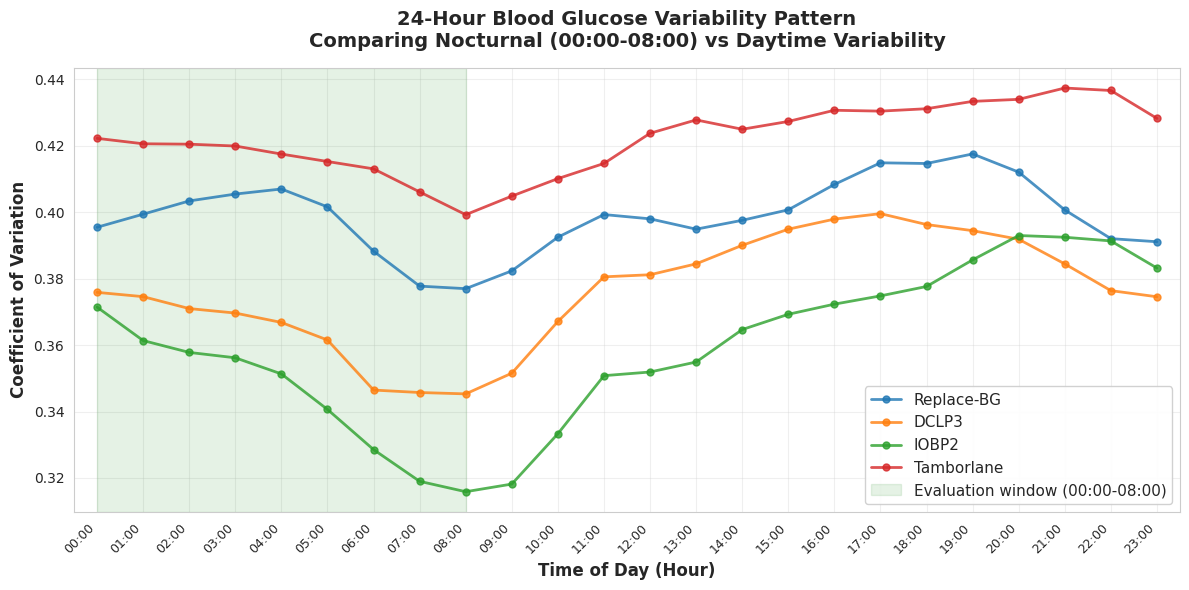

In [36]:
_plot_variance_combined(df, time_col="hr_cv_shift")

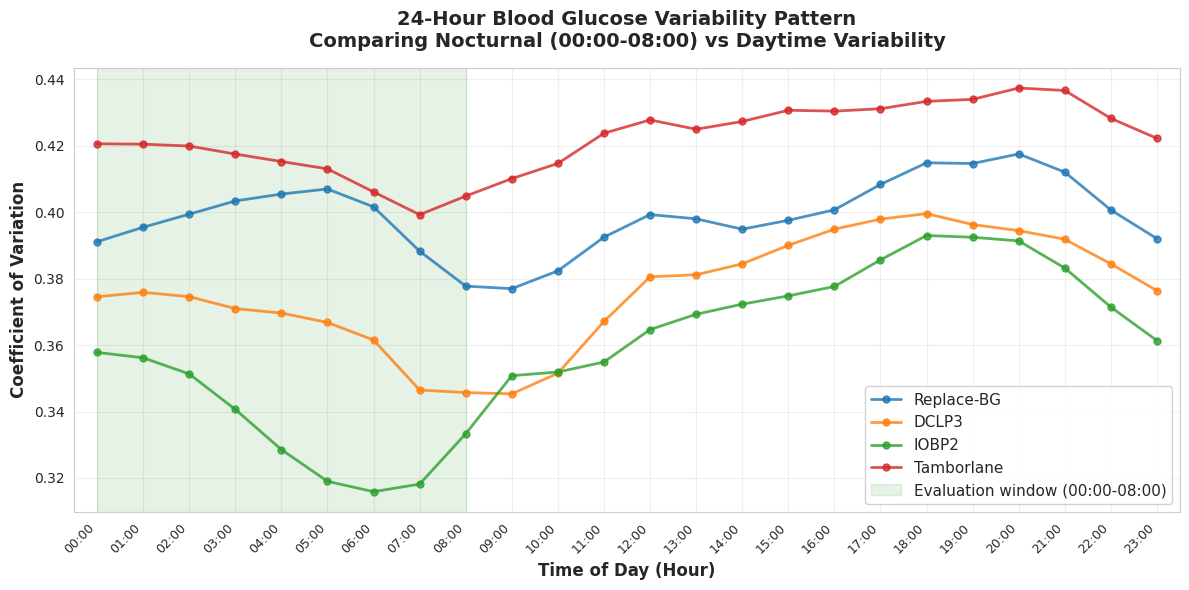

In [39]:
_plot_variance_combined(df, time_col="hour")

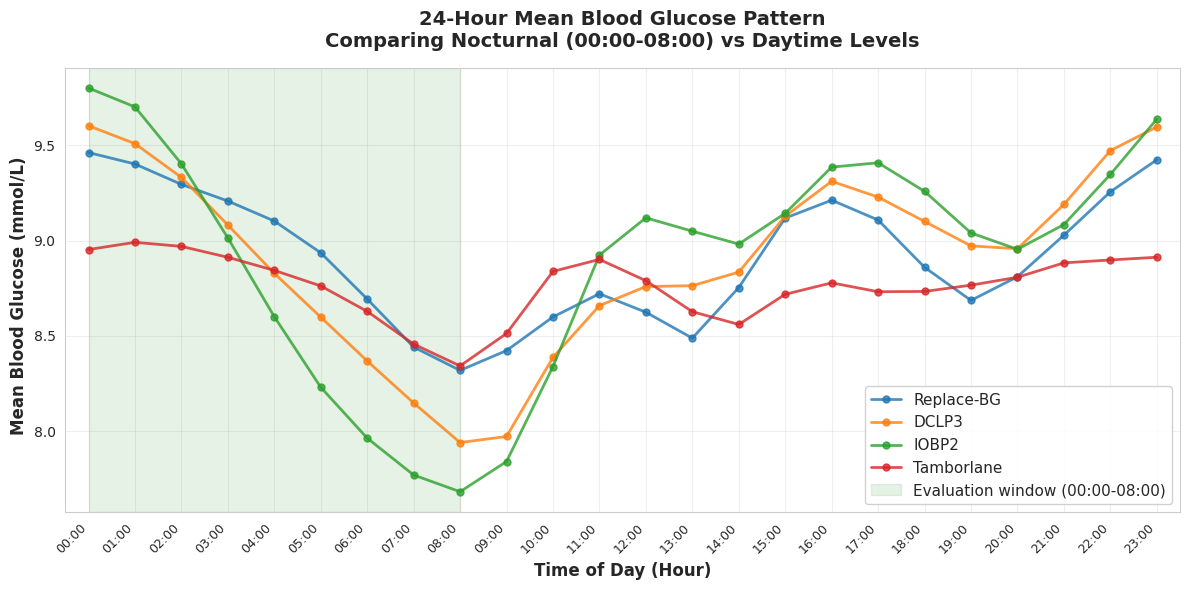

In [ ]:
_plot_mean_combined(df, time_col="hr_bg_shift")

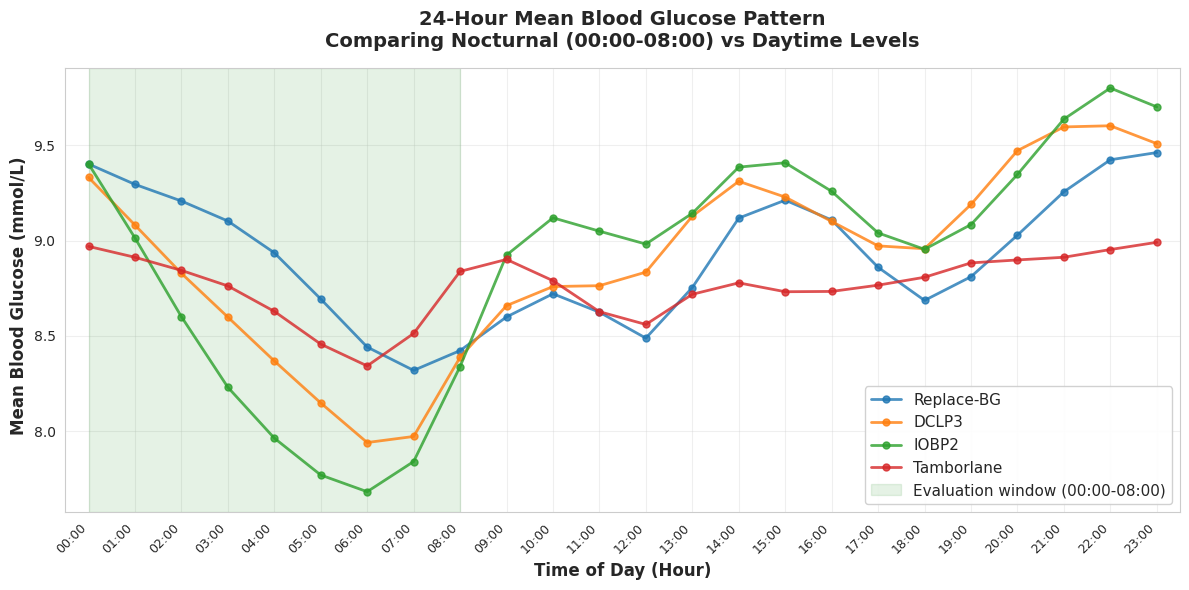

In [38]:
_plot_mean_combined(df, time_col="hour")